# 下一课：DQN + Replay Buffer + Target Network

上一课我们已经写出了一个最小版的 `DQN`：
- 用神经网络输出 Q 值
- 用 TD target 训练网络

这一课我们继续补上真实 DQN 里最关键的两个稳定器：
- `Replay Buffer`
- `Target Network`

学完这一课，你会理解：
- 为什么直接在线更新会不稳定
- 为什么要把经验存起来再随机采样
- 为什么要用一个“慢一点更新”的目标网络


## 1. 为什么上一课的最小版 DQN 还不够稳

最小版 DQN 虽然能跑，但它有两个经典问题：

1. 相邻样本太像了
   智能体一步一步走，连续两条经验高度相关。
   如果直接拿最新一条样本训练，网络容易震荡。

2. target 会跟着网络自己一起乱动
   因为我们用同一个网络既负责预测当前 Q 值，又负责算下一状态的 target。
   这样目标本身也在变，会让训练不稳定。

DQN 的经典改进，就是分别用：
- `Replay Buffer` 解决样本相关性
- `Target Network` 解决目标值不稳定


In [1]:
import random
import warnings
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


## 2. 环境还是用最简单的一维走格子

为了把注意力放在 DQN 的结构改进上，这一课环境仍然保持简单：
- 每走一步奖励 `-0.02`
- 到达终点奖励 `+1`

这样你能更容易看清 replay buffer 和 target network 到底在做什么。


In [3]:
class LineWorld:
    def __init__(self, length=6):
        self.length = length
        self.goal = length - 1
        self.reset()

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 0:
            self.position = max(0, self.position - 1)
        else:
            self.position = min(self.goal, self.position + 1)

        reward = 1.0 if self.position == self.goal else -0.02
        done = self.position == self.goal
        return self.position, reward, done


In [4]:
def state_to_tensor(state, n_states, device):
    x = torch.zeros((1, n_states), dtype=torch.float32, device=device)
    x[0, state] = 1.0
    return x


def batch_states_to_tensor(states, n_states, device):
    x = torch.zeros((len(states), n_states), dtype=torch.float32, device=device)
    for i, s in enumerate(states):
        x[i, s] = 1.0
    return x


## 3. Q 网络和目标网络

这次我们会维护两份网络：

- `q_net`：正在训练、实时更新的主网络
- `target_net`：较慢同步的目标网络

计算 target 时，不再用 `q_net` 自己，而是用 `target_net`。
这样目标值不会随着每次梯度更新剧烈变化，训练通常会稳定很多。


In [5]:
class QNetwork(nn.Module):
    def __init__(self, n_states, n_actions, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )

    def forward(self, x):
        return self.net(x)


## 4. Replay Buffer 是什么

`Replay Buffer` 就是一个经验池。

每次交互后，我们把一条经验存进去：

`(state, action, reward, next_state, done)`

然后训练时不是只用最新一条，而是从经验池里随机抽一小批样本。

这样做的好处：
- 打乱样本顺序，减少连续样本的强相关
- 同一条经验可以被复用多次，提高样本利用率


In [6]:
class ReplayBuffer:
    def __init__(self, capacity=1000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


## 5. 训练逻辑要看懂的地方

这一课最重要的是训练循环里的这些步骤：

1. 和环境交互，收集经验
2. 把经验放进 replay buffer
3. 当 buffer 足够大时，随机采样一个 batch
4. 用 `q_net` 预测当前 Q 值
5. 用 `target_net` 计算下一状态 target
6. 定期把 `q_net` 的参数复制给 `target_net`

这就是标准 DQN 的核心骨架。


In [7]:
env = LineWorld(length=6)
n_states = env.length
n_actions = 2

q_net = QNetwork(n_states, n_actions, hidden_dim=32).to(device)
target_net = QNetwork(n_states, n_actions, hidden_dim=32).to(device)

# 一开始先让目标网络和主网络完全一样
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=0.01)
criterion = nn.MSELoss()
replay_buffer = ReplayBuffer(capacity=2000)

gamma = 0.9
epsilon = 0.3
episodes = 400
max_steps = 40
batch_size = 32
target_update_freq = 20

episode_rewards = []
episode_steps = []
loss_history = []
buffer_sizes = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = state_to_tensor(state, n_states, device)

        # 用主网络预测当前状态下的动作价值
        with torch.no_grad():
            q_values = q_net(state_tensor)

        # epsilon-greedy 选动作
        if random.random() < epsilon:
            action = random.randint(0, n_actions - 1)
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, done = env.step(action)

        # 先把经验存进经验池
        replay_buffer.push(state, action, reward, next_state, done)
        buffer_sizes.append(len(replay_buffer))

        state = next_state
        total_reward += reward

        # 只有当经验池里样本够多时，才开始做 batch 训练
        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            states_tensor = batch_states_to_tensor(states, n_states, device)
            next_states_tensor = batch_states_to_tensor(next_states, n_states, device)
            actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)

            # 主网络输出当前 batch 中每个状态的动作 Q 值
            current_q_values = q_net(states_tensor)

            # 只取出每条样本里“实际执行的动作”对应的 Q 值
            chosen_q_values = current_q_values.gather(1, actions_tensor).squeeze(1)

            with torch.no_grad():
                # 目标网络负责计算下一状态的 target，避免 target 跟着主网络一起乱跳
                next_q_values = target_net(next_states_tensor)
                max_next_q_values = next_q_values.max(dim=1).values

                # done=1 时，说明 episode 已结束，不再加未来价值
                targets = rewards_tensor + gamma * max_next_q_values * (1 - dones_tensor)

            loss = criterion(chosen_q_values, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(float(loss.item()))

        if done:
            episode_steps.append(step + 1)
            break
    else:
        episode_steps.append(max_steps)

    episode_rewards.append(total_reward)
    epsilon = max(0.02, epsilon * 0.995)

    # 每隔若干轮，把主网络参数同步到目标网络
    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 3))
print('经验池最终大小:', len(replay_buffer))


训练完成。
最后 20 轮平均 reward: 0.914
经验池最终大小: 2000


## 6. 看看主网络学到了什么

训练完成后，我们把每个状态都送进 `q_net` 看看预测结果。
你会发现它依然是在学习“每个状态下两个动作谁更值”。


In [8]:
q_net.eval()
predicted_q_table = []

print('各状态下主网络预测的 Q 值：')
with torch.no_grad():
    for s in range(n_states):
        state_tensor = state_to_tensor(s, n_states, device)
        q = q_net(state_tensor).squeeze(0).detach().cpu().numpy()
        predicted_q_table.append(q)
        print(f'状态 {s}: left={q[0]:.3f}, right={q[1]:.3f}')

predicted_q_table = np.array(predicted_q_table)


各状态下主网络预测的 Q 值：
状态 0: left=0.509, right=0.587
状态 1: left=0.509, right=0.675
状态 2: left=0.587, right=0.772
状态 3: left=0.675, right=0.880
状态 4: left=0.772, right=1.000
状态 5: left=0.504, right=0.601


In [9]:
action_map = {0: '←', 1: '→'}
policy = [action_map[int(np.argmax(predicted_q_table[s]))] for s in range(n_states - 1)] + ['G']

print('主网络学到的策略：')
for s, a in enumerate(policy):
    print(f'状态 {s}: {a}')


主网络学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G


C:\Users\80740\AppData\Local\Temp\ipykernel_16876\3684939470.py:23: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16876\3684939470.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16876\3684939470.py:23: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16876\3684939470.py:23: UserWarning: Glyph 22870 (\N{CJK UNIFIED IDEOGRAPH-5956}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16876\3684939470.py:23: UserWarning: Glyph 21169 (\N{CJK UNIFIED IDEOGRAPH-52B1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_16876\3684939470.py:23: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65})

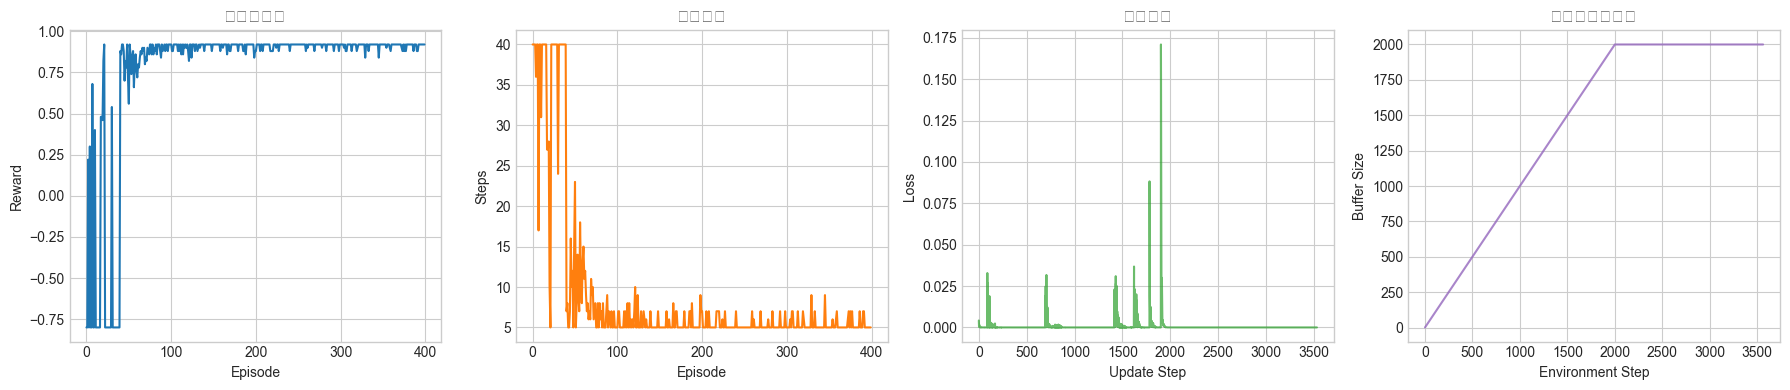

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(episode_rewards, color='#1f77b4')
axes[0].set_title('每轮总奖励')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')

axes[1].plot(episode_steps, color='#ff7f0e')
axes[1].set_title('每轮步数')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')

axes[2].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[2].set_title('训练损失')
axes[2].set_xlabel('Update Step')
axes[2].set_ylabel('Loss')

axes[3].plot(buffer_sizes, color='#9467bd', alpha=0.8)
axes[3].set_title('经验池大小变化')
axes[3].set_xlabel('Environment Step')
axes[3].set_ylabel('Buffer Size')

plt.tight_layout()
plt.show()


## 7. 你现在应该真正记住的东西

这节课最重要的不是代码细节，而是这两个设计思想：

1. `Replay Buffer`
   让训练样本更随机，减少相邻经验的相关性。

2. `Target Network`
   让 TD target 更稳定，不至于主网络一更新，老师答案也一起剧烈变化。

你可以把它理解为：

- `q_net` 是学生
- `target_net` 是更新得更慢一点的老师

学生不是直接拿自己的最新情绪当标准，而是参考一个更稳的老师去学习。


## 8. 下一课最自然学什么

现在你已经具备了标准 DQN 的基础框架。

下一课最自然的方向有两个：
- `CartPole`：第一次把 DQN 用在连续状态环境上
- `Double DQN`：进一步减少 Q 值高估问题

如果按学习路线来说，最推荐下一课先上 `CartPole + DQN`。


In [11]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()